# Swiss Roll Datasates

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_swiss_roll
from sklearn.manifold import MDS , Isomap , TSNE

In [3]:
x , y = make_swiss_roll(n_samples=500)
x[:, 2]=0.6*x[:, 2]

In [4]:
x.shape

(500, 3)

In [5]:
print (x.max(axis=0)-x.min(axis=0))

[22.08218959 20.896936   15.10389787]


In [6]:
import plotly.express as px

In [7]:
px.scatter_3d(x=X[:, 0],
             y=X[:, 1],
             z=X[:, 2],
              color=y)

In [8]:
from sklearn.decomposition import PCA

In [9]:
pca = PCA(n_components=2)
X_2d_pca = pca.fit_transform(x)

In [10]:
px.scatter(x=X_2d_pca[:, 0],
           y=X_2d_pca[:, 1],
           color=y)

In [11]:
mds = MDS(n_components=2)
X_2d_mds = mds.fit_transform(x)

C:\Users\DELL\miniconda3\lib\site-packages\sklearn\manifold\_mds.py:298: FutureWarning:

The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.



In [12]:
px.scatter(x=X_2d_mds[:, 0],
           y=X_2d_mds[:, 1],
           color=y)

In [13]:
iso = Isomap(n_components=2)
X_2d_iso = iso.fit_transform(x)

In [14]:
px.scatter(x=X_2d_iso[:, 0],
           y=X_2d_iso[:, 1],
           color=y)

In [15]:
tsne = TSNE(n_components=2)
X_2d_tsne = tsne.fit_transform(x)

In [16]:
px.scatter(x=X_2d_tsne[:, 0],
           y=X_2d_tsne[:, 1],
           color=y)

Text(0.5, 1.0, 'TSNE')

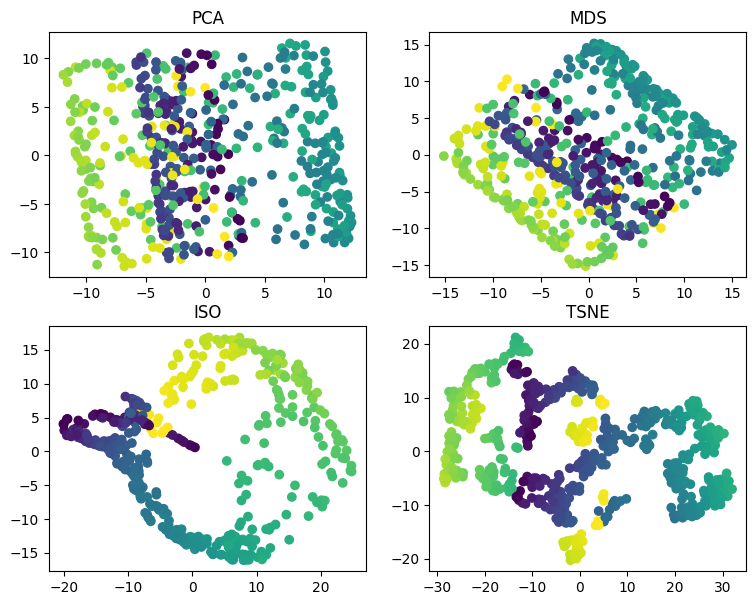

In [17]:
plt.figure(figsize=(9,7))

plt.subplot(221)
plt.scatter(x=X_2d_pca[:, 0],
           y=X_2d_pca[:, 1],
           c=y)
plt.title('PCA')

plt.subplot(222)
plt.scatter(x=X_2d_mds[:, 0],
           y=X_2d_mds[:, 1],
           c=y)
plt.title('MDS')

plt.subplot(223)
plt.scatter(x=X_2d_iso[:, 0],
           y=X_2d_iso[:, 1],
           c=y)
plt.title('ISO')

plt.subplot(224)
plt.scatter(x=X_2d_tsne[:, 0],
           y=X_2d_tsne[:, 1],
           c=y)
plt.title('TSNE')

In [18]:
import timeit

In [19]:
N = 1000
start = timeit.default_timer()

for n in range(N):
    x_2d_pca = PCA(n_components=2).fit_transform(X)

stop = timeit.default_timer()
print('Time PCA :', stop-start)

Time PCA : 0.6166344000957906


# Hand Written Digits:

In [21]:
from sklearn.datasets import load_digits

In [24]:
X , y = load_digits(return_X_y =True)

In [25]:
print(x.shape , y.shape)

(500, 3) (1797,)


In [26]:
X_2d_pca = PCA(n_components=2).fit_transform(X)

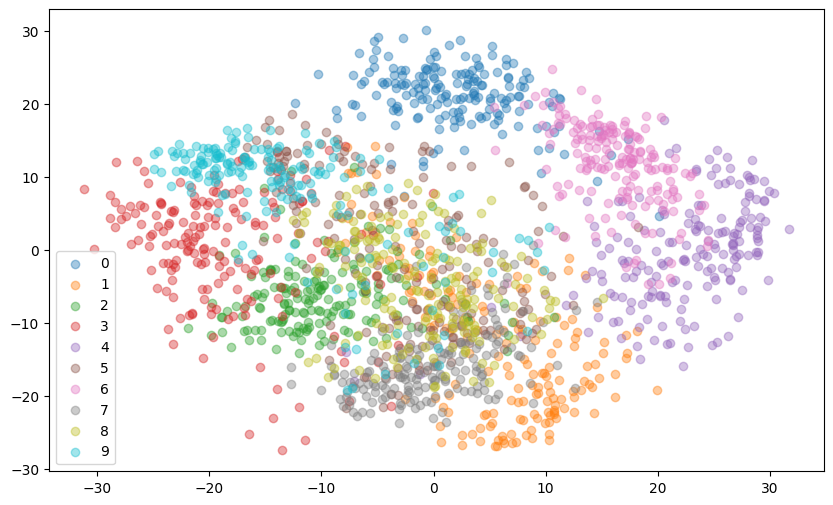

In [28]:
plt.figure(figsize=(10 , 6))
for i in range (10):
    plt.scatter(X_2d_pca[y==i , 0],
                X_2d_pca[y==i , 1],
                alpha = 0.4 ,
                label = str(i))
plt.legend();

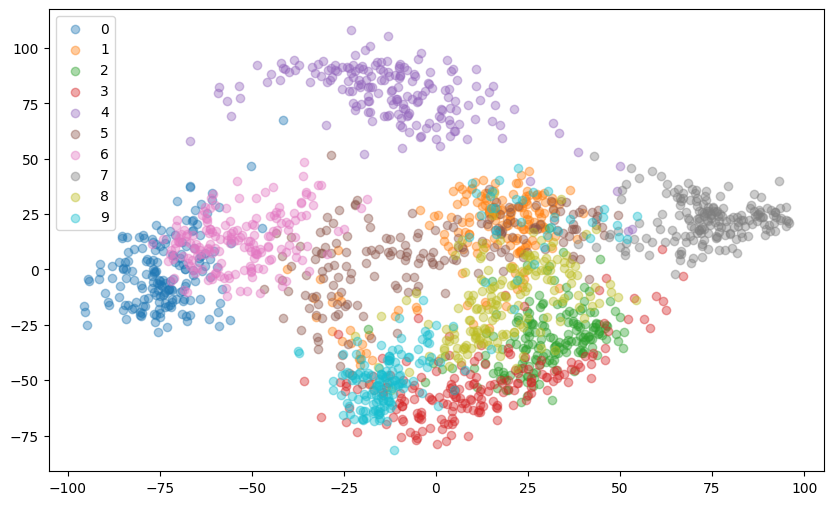

In [29]:
X_2d_iso = Isomap(n_components=2,n_neighbors=20).fit_transform(X)
plt.figure(figsize=(10 , 6))
for i in range (10):
    plt.scatter(X_2d_iso[y==i , 0],
                X_2d_iso[y==i , 1],
                alpha = 0.4 ,
                label = str(i))
plt.legend();

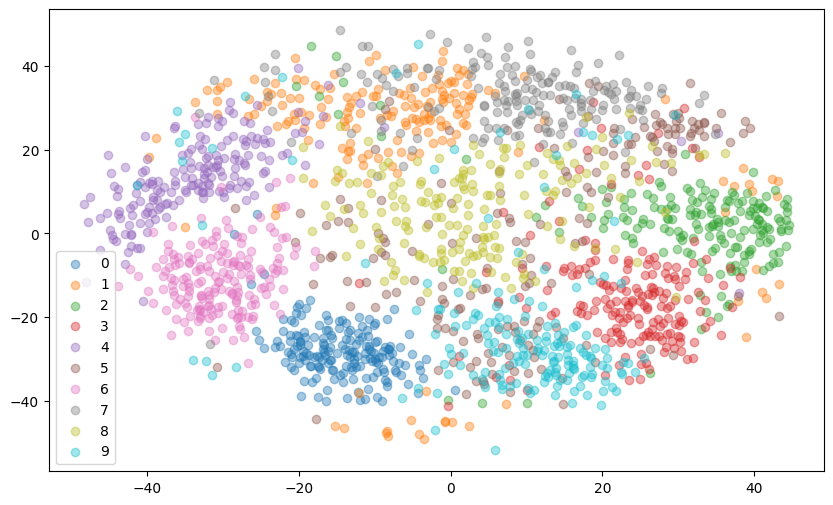

In [30]:
X_2d_mds = MDS(n_components=2,normalized_stress='auto').fit_transform(X)
plt.figure(figsize=(10 , 6))
for i in range (10):
    plt.scatter(X_2d_mds[y==i , 0],
                X_2d_mds[y==i , 1],
                alpha = 0.4 ,
                label = str(i))
plt.legend();

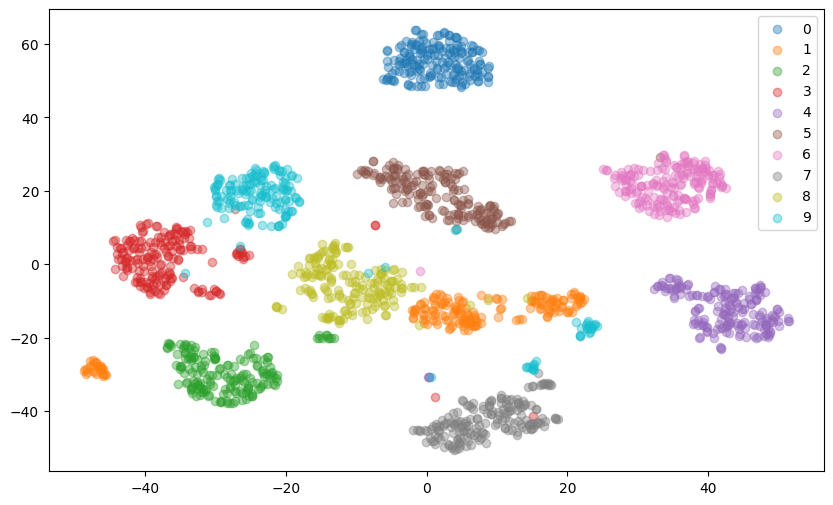

In [31]:
X_2d_tsne = TSNE(n_components=2).fit_transform(X)
plt.figure(figsize=(10 , 6))
for i in range (10):
    plt.scatter(X_2d_tsne[y==i , 0],
                X_2d_tsne[y==i , 1],
                alpha = 0.4 ,
                label = str(i))
plt.legend();

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier as KNN

In [34]:
X_train , X_test , y_train , y_test = train_test_split(X,y,
                                                      test_size=0.3,
                                                      random_state=1111)

In [35]:
print(X_train.shape , y_train.shape)
print(X_test.shape , y_test.shape)

(1257, 64) (1257,)
(540, 64) (540,)


In [76]:
clf1 = KNN(n_neighbors=5)

clf2 = Pipeline(steps=[('Dimention Reduction',PCA(n_components=2)),
                       ('Classifier',KNN(n_neighbors=5))])

#clf3 = Pipeline(steps=[('Dimention Reduction'),MDS(n_components=2),
                       #('Classifier',KNN(n_neighbors=5))])

clf4 = Pipeline(steps=[('Dimention Reduction',Isomap(n_components=2,n_neighbors=9)),
                       ('Classifier',KNN(n_neighbors=5))])

#clf5 = Pipeline(steps=[('Dimention Reduction'),TSNE(n_components=2),
                       #('Classifier',KNN(n_neighbors=5))])

In [77]:
clfs = [clf1 , clf2 , clf4]

In [78]:
for clf in clfs:
    clf.fit(X_train , y_train)

In [79]:
from sklearn.metrics import accuracy_score

In [80]:
for clf in clfs :
    print(accuracy_score(y_true=y_test,y_pred=clf.predict(X_test)))

0.987037037037037
0.65
0.8203703703703704


In [92]:
n_component=[]
ACC_iso=[]
ACC_pca=[]
for n in range(1,60):
    clf1 = Pipeline(steps=[('Dimention Reduction',PCA(n_components=n)),
                       ('Classifier',KNN(n_neighbors=5))])
    clf2 = Pipeline(steps=[('Dimention Reduction',Isomap(n_components=n,n_neighbors=9)),
                       ('Classifier',KNN(n_neighbors=5))])
    clf1.fit(X_train,y_train)
    clf2.fit(X_train,y_train)

    ACC_pca.append(accuracy_score(y_true=y_test,y_pred=clf1.predict(X_test)))
    ACC_iso.append(accuracy_score(y_true=y_test,y_pred=clf2.predict(X_test)))
    n_component.append(n)
    print(n)

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59


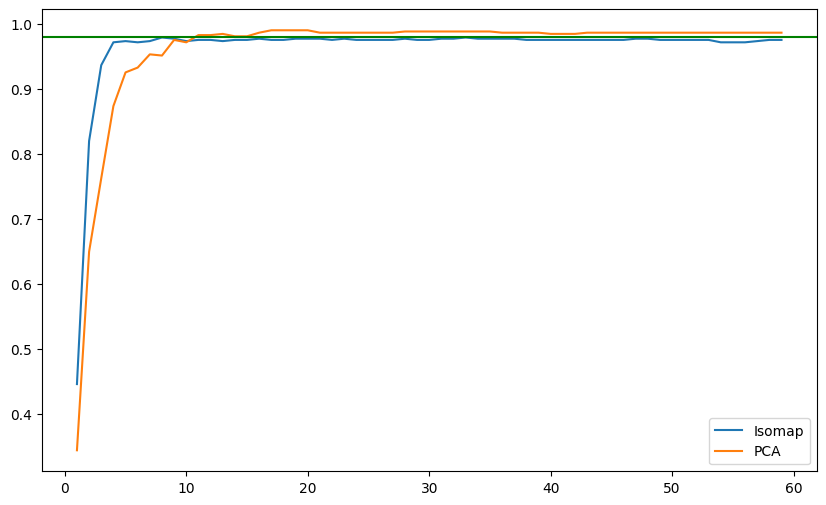

In [95]:
plt.figure(figsize=(10,6))
plt.plot(n_component,ACC_iso,label='Isomap')
plt.plot(n_component,ACC_pca,label='PCA')
plt.axhline(0.98,c='green')
plt.legend()

In [96]:
#END